# Origin Classification with TF-IDF

Baseline pipeline for country-level origin classification using tasting text.

In [29]:
import re
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, f1_score
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt


In [30]:
DATA_PATH = 'Data/final_coffee_reviews.csv'
RANDOM_STATE = 42
MIN_SAMPLES_PER_CLASS = 30

df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
df.head(2)

Shape: (7585, 25)


,URL,all_text,Rating,Roaster,Coffee Name,Roaster Location,Coffee Origin,Roast Level,Agtron,Est. Price,...,Flavor,Aftertaste,With Milk,Blind Assessment,Notes,Who Should Drink It,Bottom Line,Combined_Acidity,Country_all,Country
0,https://www.coffeereview.com/review/100-arabic...,87\nCaribeans\n100% Arabica Coffee from Puerto...,87.0,Caribeans,100% Arabica Coffee from Puerto Rico,"San Juan, Puerto Rico","Utuado, central Puerto Rico",Medium-Light,54/69,$17.00/8 ounces,...,8.0,7.0,NaN,bittersweet but balanced; chocolaty. dark choc...,Produced on a single farm in the central mount...,NaN,Satisfying chocolate and nut notes nearly carr...,7.0,Puerto Rico; China,Puerto Rico
1,https://www.coffeereview.com/review/100-arabic...,88\nWaka Coffee\n100% Arabica Freeze-Dried Col...,88.0,Waka Coffee,100% Arabica Freeze-Dried Colombian (Instant C...,"Los Angeles, California",Colombia,NaN,0/0,$10.99/8 single-serve packets,...,8.0,8.0,NaN,evaluated at proportions of 5 grams of instant...,The green coffee for this product was produced...,NaN,A appealing 100% Colombia coffee in instant fo...,7.0,Colombia,Colombia


In [31]:
def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.lower().strip()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text


In [32]:
# Build text input (tasting-focused)
df['text_main'] = df['Blind Assessment'].fillna('').map(normalize_text)

# Use the country label prepared in notebook 01
df['origin_country'] = df['Country'].astype('string').str.strip()
df['origin_country'] = df['origin_country'].replace('', pd.NA)

# Keep valid rows only
work = df[(df['text_main'].str.len() >= 30) & (df['origin_country'].notna())].copy()

# Remove tiny classes for a stable baseline
counts = work['origin_country'].value_counts()
valid_classes = counts[counts >= MIN_SAMPLES_PER_CLASS].index
work = work[work['origin_country'].isin(valid_classes)].copy()

print('Rows after filtering:', len(work))
print('Num classes:', work['origin_country'].nunique())
work['origin_country'].value_counts().head(15)

Rows after filtering: 7437
Num classes: 25


origin_country
Ethiopia         1996
Colombia          988
Kenya             699
Guatemala         561
Indonesia         452
Costa Rica        373
Panama            354
United States     302
El Salvador       240
Brazil            200
Rwanda            176
Peru              130
Nicaragua         125
Honduras          123
Mexico            101
Name: count, dtype: Int64

In [33]:
dataset_summary = pd.DataFrame({
    'metric': [
        'Rows in raw dataset',
        'Rows after preprocessing/filtering',
        'Unique origin classes after filtering',
        'Minimum samples per class',
        'Review date min',
        'Review date max',
    ],
    'value': [
        len(df),
        len(work),
        work['origin_country'].nunique(),
        MIN_SAMPLES_PER_CLASS,
        df['Review Date'].min(),
        df['Review Date'].max(),
    ]
})

dataset_summary


,metric,value
0,Rows in raw dataset,7585
1,Rows after preprocessing/filtering,7437
2,Unique origin classes after filtering,25
3,Minimum samples per class,30
4,Review date min,1997-02-01
5,Review date max,2026-03-01


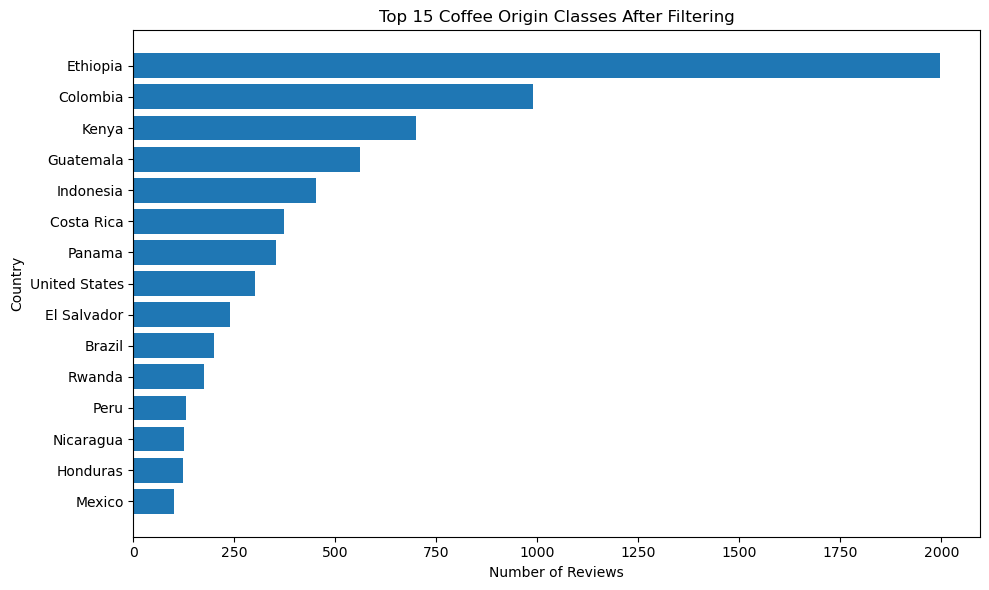

In [34]:
origin_counts = work['origin_country'].value_counts().head(15).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(origin_counts.index, origin_counts.values)
plt.xlabel('Number of Reviews')
plt.ylabel('Country')
plt.title('Top 15 Coffee Origin Classes After Filtering')
plt.tight_layout()
plt.show()


In [35]:
X = work['text_main']
y = work['origin_country']

# 70/15/15 split (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print('Train:', len(X_train), 'Val:', len(X_val), 'Test:', len(X_test))

Train: 5205 Val: 1116 Test: 1116


In [36]:
tfidf_lr = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.90,
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        max_iter=5000,
        solver='liblinear',
        class_weight='balanced',
        multi_class='ovr',
        random_state=RANDOM_STATE
    ))
])

tfidf_lr.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, min_df=3, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=5000,
                                    multi_class='ovr', random_state=42,
                                    solver='liblinear'))])

In [37]:
def evaluate(model, X_data, y_true, split_name='split'):
    y_pred = model.predict(X_data)
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

    print(f'== {split_name} ==')
    print(f'Accuracy:  {acc:.4f}')
    print(f'Precision: {p:.4f}')
    print(f'Recall:    {r:.4f}')
    print(f'F1-macro:  {f1:.4f}')

    return y_pred


_ = evaluate(tfidf_lr, X_val, y_val, 'Validation')
y_test_pred = evaluate(tfidf_lr, X_test, y_test, 'Test')

print('\nTop classes report (test):')
top_labels = y_test.value_counts().head(15).index
print(classification_report(y_test, y_test_pred, labels=top_labels, zero_division=0))

== Validation ==
Accuracy:  0.2464
Precision: 0.1244
Recall:    0.1429
F1-macro:  0.1230
== Test ==
Accuracy:  0.2554
Precision: 0.1417
Recall:    0.1600
F1-macro:  0.1390

Top classes report (test):
               precision    recall  f1-score   support

     Ethiopia       0.46      0.39      0.42       300
     Colombia       0.31      0.09      0.14       148
        Kenya       0.51      0.54      0.53       105
    Guatemala       0.26      0.11      0.15        84
    Indonesia       0.34      0.60      0.44        68
   Costa Rica       0.25      0.07      0.11        56
       Panama       0.13      0.19      0.15        53
United States       0.10      0.11      0.10        45
  El Salvador       0.06      0.06      0.06        36
       Brazil       0.20      0.30      0.24        30
       Rwanda       0.08      0.11      0.09        27
         Peru       0.08      0.15      0.11        20
    Nicaragua       0.06      0.05      0.05        19
     Honduras       0.00     

In [38]:
# Optional: preview predictions
preview = pd.DataFrame({
    'text': X_test.head(5).values,
    'true_origin': y_test.head(5).values,
    'pred_origin': tfidf_lr.predict(X_test.head(5))
})
preview

,text,true_origin,pred_origin
0,richly berry and citrus-toned; bright and live...,Taiwan,United States
1,"sweet-toned, fruit-forward. raspberry, cedar, ...",United States,Honduras
2,"evaluated as espresso. richly chocolaty, nut-t...",Colombia,Ethiopia
3,"balanced, crisply fruity. black cherry, pink g...",Costa Rica,Rwanda
4,"richly sweet, subtly floral. butterscotch, hop...",Rwanda,Burundi


In [39]:
tfidf_svm = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.90,
        sublinear_tf=True
    )),
    ('clf', LinearSVC(
        C=1.0,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

tfidf_svm.fit(X_train, y_train)


g:\Anaconda\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, min_df=3, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('clf', LinearSVC(class_weight='balanced', random_state=42))])

In [40]:
_ = evaluate(tfidf_svm, X_val, y_val, 'Validation (Linear SVM)')
y_test_pred_svm = evaluate(tfidf_svm, X_test, y_test, 'Test (Linear SVM)')

print('\nTop classes report (test, Linear SVM):')
top_labels = y_test.value_counts().head(15).index
print(classification_report(y_test, y_test_pred_svm, labels=top_labels, zero_division=0))


== Validation (Linear SVM) ==
Accuracy:  0.2545
Precision: 0.1222
Recall:    0.1380
F1-macro:  0.1261
== Test (Linear SVM) ==
Accuracy:  0.2661
Precision: 0.1414
Recall:    0.1474
F1-macro:  0.1405

Top classes report (test, Linear SVM):
               precision    recall  f1-score   support

     Ethiopia       0.49      0.36      0.42       300
     Colombia       0.31      0.19      0.23       148
        Kenya       0.41      0.51      0.46       105
    Guatemala       0.26      0.21      0.23        84
    Indonesia       0.34      0.57      0.43        68
   Costa Rica       0.16      0.12      0.14        56
       Panama       0.14      0.19      0.16        53
United States       0.11      0.16      0.13        45
  El Salvador       0.05      0.06      0.05        36
       Brazil       0.21      0.27      0.24        30
       Rwanda       0.09      0.11      0.10        27
         Peru       0.15      0.20      0.17        20
    Nicaragua       0.00      0.00      0.00  

In [41]:
# Reduced search space so tuning finishes in a reasonable time on local hardware
search_space = [
    {
        'model_name': ['Logistic Regression'],
        'analyzer': ['word'],
        'ngram_range': [(1, 1), (1, 2)],
        'min_df': [2, 5],
        'max_df': [0.90],
        'sublinear_tf': [True],
        'C': [1, 5],
    },
    {
        'model_name': ['Linear SVM'],
        'analyzer': ['word'],
        'ngram_range': [(1, 1), (1, 2)],
        'min_df': [2, 5],
        'max_df': [0.90],
        'sublinear_tf': [True],
        'C': [1, 5],
    },
    {
        'model_name': ['Logistic Regression'],
        'analyzer': ['char_wb'],
        'ngram_range': [(3, 5)],
        'min_df': [2, 5],
        'max_df': [0.90],
        'sublinear_tf': [True],
        'C': [1, 5],
    },
    {
        'model_name': ['Linear SVM'],
        'analyzer': ['char_wb'],
        'ngram_range': [(3, 5)],
        'min_df': [2, 5],
        'max_df': [0.90],
        'sublinear_tf': [True],
        'C': [1, 5],
    },
]

search_results = []
best_model = None
best_params = None
best_val_f1 = -1
print('Total tuned configurations:', sum(len(list(ParameterGrid(grid))) for grid in search_space))

for grid in search_space:
    for params in ParameterGrid(grid):
        vectorizer = TfidfVectorizer(
            analyzer=params['analyzer'],
            ngram_range=params['ngram_range'],
            min_df=params['min_df'],
            max_df=params['max_df'],
            sublinear_tf=params['sublinear_tf'],
        )

        if params['model_name'] == 'Logistic Regression':
            clf = LogisticRegression(
                C=params['C'],
                max_iter=5000,
                solver='liblinear',
                class_weight='balanced',
                multi_class='ovr',
                random_state=RANDOM_STATE,
            )
        else:
            clf = LinearSVC(
                C=params['C'],
                class_weight='balanced',
                dual='auto',
                max_iter=10000,
                random_state=RANDOM_STATE,
            )

        model = Pipeline([
            ('tfidf', vectorizer),
            ('clf', clf),
        ])

        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)
        val_f1 = f1_score(y_val, y_val_pred, average='macro', zero_division=0)

        row = dict(params)
        row['val_f1_macro'] = val_f1
        search_results.append(row)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_params = dict(params)
            best_model = model

search_results_df = pd.DataFrame(search_results).sort_values('val_f1_macro', ascending=False).reset_index(drop=True)
search_results_df.head(10)


Total tuned configurations: 24


,C,analyzer,max_df,min_df,model_name,ngram_range,sublinear_tf,val_f1_macro
0,5,char_wb,0.9,2,Logistic Regression,"(3, 5)",True,0.131204
1,1,word,0.9,2,Logistic Regression,"(1, 1)",True,0.126958
2,1,char_wb,0.9,2,Logistic Regression,"(3, 5)",True,0.125328
3,5,char_wb,0.9,5,Logistic Regression,"(3, 5)",True,0.124784
4,1,char_wb,0.9,2,Linear SVM,"(3, 5)",True,0.122794
5,1,char_wb,0.9,5,Logistic Regression,"(3, 5)",True,0.122320
6,5,word,0.9,2,Logistic Regression,"(1, 2)",True,0.121980
7,1,word,0.9,5,Logistic Regression,"(1, 1)",True,0.121395
8,1,char_wb,0.9,5,Linear SVM,"(3, 5)",True,0.121130
9,1,word,0.9,2,Logistic Regression,"(1, 2)",True,0.120973


In [42]:
print('Best validation F1-macro:', round(best_val_f1, 4))
best_params


Best validation F1-macro: 0.1312


{'C': 5,
 'analyzer': 'char_wb',
 'max_df': 0.9,
 'min_df': 2,
 'model_name': 'Logistic Regression',
 'ngram_range': (3, 5),
 'sublinear_tf': True}

In [43]:
_ = evaluate(best_model, X_val, y_val, 'Validation (Best Tuned TF-IDF Model)')
y_test_pred_best = evaluate(best_model, X_test, y_test, 'Test (Best Tuned TF-IDF Model)')

print('\nTop classes report (test, best tuned model):')
top_labels = y_test.value_counts().head(15).index
print(classification_report(y_test, y_test_pred_best, labels=top_labels, zero_division=0))


== Validation (Best Tuned TF-IDF Model) ==
Accuracy:  0.2590
Precision: 0.1335
Recall:    0.1425
F1-macro:  0.1312
== Test (Best Tuned TF-IDF Model) ==
Accuracy:  0.2599
Precision: 0.1402
Recall:    0.1619
F1-macro:  0.1442

Top classes report (test, best tuned model):
               precision    recall  f1-score   support

     Ethiopia       0.53      0.36      0.43       300
     Colombia       0.33      0.14      0.20       148
        Kenya       0.53      0.50      0.52       105
    Guatemala       0.20      0.15      0.18        84
    Indonesia       0.40      0.57      0.47        68
   Costa Rica       0.09      0.07      0.08        56
       Panama       0.14      0.21      0.17        53
United States       0.10      0.13      0.11        45
  El Salvador       0.15      0.19      0.17        36
       Brazil       0.16      0.27      0.20        30
       Rwanda       0.11      0.19      0.14        27
         Peru       0.06      0.10      0.08        20
    Nicaragua 

In [ ]:
def metric_row(model, label, X_val_data, X_test_data):
    y_val_pred = model.predict(X_val_data)
    y_test_pred = model.predict(X_test_data)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_p, val_r, val_f1, _ = precision_recall_fscore_support(y_val, y_val_pred, average='macro', zero_division=0)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_p, test_r, test_f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='macro', zero_division=0)

    return {
        'model': label,
        'val_accuracy': val_acc,
        'val_precision_macro': val_p,
        'val_recall_macro': val_r,
        'val_f1_macro': val_f1,
        'test_accuracy': test_acc,
        'test_precision_macro': test_p,
        'test_recall_macro': test_r,
        'test_f1_macro': test_f1,
    }

comparison_df = pd.DataFrame([
    metric_row(tfidf_lr, 'TF-IDF + Logistic Regression (Baseline)', X_val, X_test),
    metric_row(tfidf_svm, 'TF-IDF + Linear SVM (Baseline)', X_val, X_test),
    metric_row(best_model, 'TF-IDF + Best Tuned Model', X_val, X_test),
]).sort_values('test_f1_macro', ascending=False).reset_index(drop=True)

comparison_df


,model,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
0,TF-IDF + Best Tuned Model,0.258961,0.133542,0.142504,0.131204,0.259857,0.140159,0.161924,0.144206
1,TF-IDF + Linear SVM (Baseline),0.254480,0.122198,0.138009,0.126110,0.266129,0.141432,0.147441,0.140547
2,TF-IDF + Logistic Regression (Baseline),0.246416,0.124369,0.142888,0.122964,0.255376,0.141660,0.160024,0.138987


: 